# Entrega 2 — Análisis exploratorio del detector de réplicas sísmicas

Perfil del dataset, cuatro hipótesis y tabla de columnas candidatas para el
modelo de la Unidad 3. Corre sobre el entregable de `publish_csv`:
`clusters_*.csv` (una fila = una secuencia sísmica, clave `cluster_id`,
objetivo `n_aftershocks`) y, como tabla complementaria, `events_*.csv` (una
fila = un terremoto, clave `id`, objetivo `is_aftershock`). Ver
`docs/EXPLICACION_PROYECTO.md` y el `README.md` de la raíz para el detalle del
método (vecino más cercano de Zaliapin & Ben-Zion).

## Qué cambió desde la Entrega 1

El pipeline se refactorizó a inglés (columnas, identificadores, logs y rutas)
después de la Entrega 1, así que este notebook lee `clusters_*.csv` /
`events_*.csv` con nombres en inglés (`n_aftershocks`, `n_foreshocks`,
`generation`, ...), no los nombres en español de la primera entrega. La
pregunta del proyecto no cambió: dado un sismo principal, ¿cuántas réplicas va
a tener?

In [1]:
import glob

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)

# Paleta categórica fija (orden fijo, no se cicla) y una escala secuencial de
# un solo tono para magnitudes — mismos valores que usa el resto del proyecto
# para gráficos.
BLUE = "#2a78d6"     # slot 1 — serie principal / secuencial
ORANGE = "#eb6834"   # slot 2 — segunda serie categórica
GRAY = "#8a8a86"      # referencias / líneas auxiliares

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#d8d7d2",
    "axes.grid": True,
    "grid.color": "#e8e7e2",
    "grid.linewidth": 0.8,
    "font.size": 10,
})

In [2]:
CLUSTERS_PATH = glob.glob("../clusters_earthquake_*mainshock=*_seed=*.csv")[0]
EVENTS_PATH = glob.glob("../events_earthquake_*mainshock=*_seed=*.csv")[0]

df = pd.read_csv(CLUSTERS_PATH)          # el dataset principal de esta entrega
events = pd.read_csv(EVENTS_PATH)        # tabla complementaria, evento por evento

print("clusters:", CLUSTERS_PATH.split("/")[-1])
print("events:  ", EVENTS_PATH.split("/")[-1])

clusters: ..\clusters_earthquake_starttime=2016-01-01_endtime=2026-01-01_minmagnitude=3.5_bbox=-55,-21,-74,-53_mainshock=largest_seed=1.csv
events:   ..\events_earthquake_starttime=2016-01-01_endtime=2026-01-01_minmagnitude=3.5_bbox=-55,-21,-74,-53_mainshock=largest_seed=1.csv


## 1. Perfil del dataset — `clusters_*.csv` (el entregable principal)

Una fila es **una secuencia sísmica**: un sismo principal con todas las
réplicas y premonitores que el método del vecino más cercano le atribuyó.
Clave `cluster_id` (id del evento raíz del árbol). Columna objetivo:
`n_aftershocks`.

In [3]:
df.shape

(1978, 15)

In [4]:
df.dtypes.value_counts()

float64    6
str        4
int64      4
bool       1
Name: count, dtype: int64

In [5]:
nulos = df.isna().mean().sort_values(ascending=False)
nulos

cluster_id           0.0
mainshock_id         0.0
mainshock_place      0.0
mainshock_mag        0.0
mainshock_time       0.0
mainshock_lat        0.0
mainshock_lon        0.0
mainshock_depth      0.0
n_events             0.0
n_aftershocks        0.0
n_foreshocks         0.0
duration_days        0.0
extent_km            0.0
max_generation       0.0
root_is_mainshock    0.0
dtype: float64

In [6]:
constantes = df.columns[df.nunique() <= 1].tolist()
constantes

[]

In [7]:
duplicados_clave = df["cluster_id"].duplicated().sum()
duplicados_clave

np.int64(0)

In [8]:
# cluster_id es la clave formal, pero mainshock_id también debería ser único:
# cada terremoto es "el principal" de una sola secuencia.
df["mainshock_id"].duplicated().sum()

np.int64(0)

### La distribución del objetivo (`n_aftershocks`)

El número más importante de la entrega.

In [9]:
ceros = int((df.n_aftershocks == 0).sum())
total = len(df)
print(f"clusters con 0 réplicas: {ceros} / {total} = {ceros/total:.2%}")
df.n_aftershocks.describe()

clusters con 0 réplicas: 1847 / 1978 = 93.38%


count    1978.000000
mean        0.141052
std         1.125339
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        32.000000
Name: n_aftershocks, dtype: float64

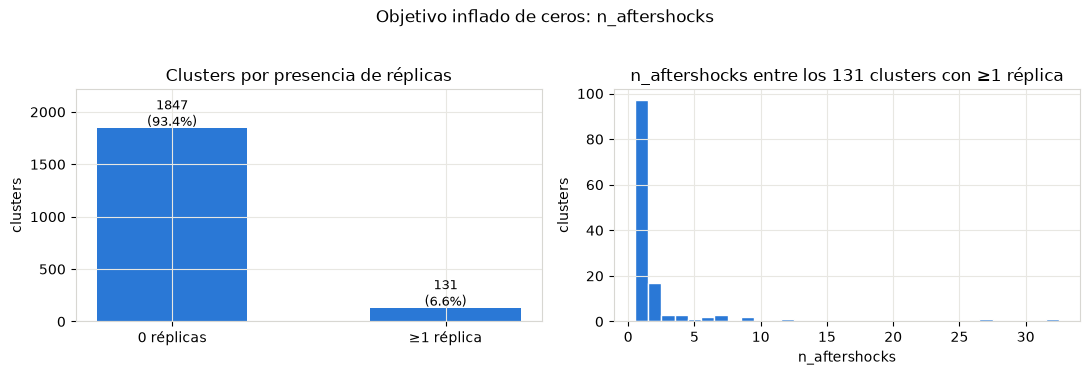

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

conteo = df.n_aftershocks.eq(0).map({True: "0 réplicas", False: "≥1 réplica"}).value_counts()
axes[0].bar(conteo.index, conteo.values, color=BLUE, width=0.55)
axes[0].set_title("Clusters por presencia de réplicas")
axes[0].set_ylabel("clusters")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 20, f"{v}\n({v/total:.1%})", ha="center", fontsize=9)
axes[0].set_ylim(0, total * 1.12)

con_replicas = df.loc[df.n_aftershocks > 0, "n_aftershocks"]
axes[1].hist(con_replicas, bins=range(1, con_replicas.max() + 2), color=BLUE,
             edgecolor="white", align="left")
axes[1].set_title(f"n_aftershocks entre los {len(con_replicas)} clusters con ≥1 réplica")
axes[1].set_xlabel("n_aftershocks")
axes[1].set_ylabel("clusters")

fig.suptitle("Objetivo inflado de ceros: n_aftershocks", y=1.03, fontsize=12)
fig.tight_layout()
plt.show()

In [11]:
asimetria = df.select_dtypes("number").skew().sort_values()
asimetria

mainshock_lat      -1.277751
mainshock_lon       0.690653
mainshock_depth     2.081619
mainshock_mag       2.370335
max_generation      8.286410
n_aftershocks      20.132167
n_events           22.354058
n_foreshocks       22.438187
extent_km          24.930532
duration_days      26.016493
dtype: float64

### Lo que hay que saber explicar de este perfil

- **Nulos:** ninguna columna tiene nulos en esta corrida (`isna().mean()` da
  0.0 en las 15). No hay que confundir esto con "no hay estructura faltante en
  el dominio" — los clusters de un solo evento tienen `duration_days = 0` y
  `extent_km = 0`, que son **ceros legítimos** (no hubo ningún otro evento del
  cual medir duración o extensión), no nulos.
- **Constantes / duplicados:** no hay columnas constantes ni duplicados de
  `cluster_id` — `publish_csv` hace fallar la corrida si alguno de los dos
  pasa, así que si el notebook llegó hasta acá es porque el pipeline ya los
  garantizó. `mainshock_id` también da cero duplicados: cada terremoto es
  sismo principal de una sola secuencia (tiene sentido — si fuera principal
  de dos, esas dos secuencias serían en realidad una).
- **Por qué `mainshock_mag` arranca en 4.5 y no en 3.5:** la consulta al USGS
  pidió `minmagnitude=3.5`, pero el pipeline recorta el catálogo a la
  magnitud de completitud (**Mc=4.50**, estimada por máxima curvatura — ver
  `README.md`) antes de correr el método. Por debajo de Mc el catálogo global
  del USGS no ve todos los sismos chicos de Argentina (los tiene el INPRES,
  no una red global), así que dejarlos adentro ensuciaría la métrica η. No es
  un filtro de esta entrega: ya viene aplicado en `nearest_neighbor`.
- **El objetivo:** `n_aftershocks` está fuertemente inflado de ceros — ~93%
  de los clusters no tuvieron ninguna réplica identificada. Esto **no es un
  error del pipeline**: la mayoría de los sismos M≥3.5 en el catálogo
  simplemente no dispara una secuencia de réplicas por encima de la magnitud
  de completitud (Mc=4.5). Es el punto 7.6 que quedó abierto de la Entrega 1
  — se retoma en la sección 4.
- **Asimetría:** todas las columnas de conteo/extensión (`n_aftershocks`,
  `n_events`, `n_foreshocks`, `duration_days`, `extent_km`, `max_generation`)
  tienen cola larga hacia la derecha (skew > 8), consistente con el mismo
  inflado de ceros — unos pocos clusters grandes (el mayor con 32 réplicas)
  estiran la distribución. Para modelar, candidatas a transformación
  logarítmica (`log1p`).

## 1.b Perfil complementario — `events_*.csv`

Una fila es **un terremoto**, con a qué cluster cayó. Clave `id`. Columna
objetivo `is_aftershock` (la clasificación por sorteo/thinning, no el corte
duro).

In [12]:
print("shape:", events.shape)
print()
print(events.dtypes.value_counts())

shape: (2321, 24)

float64    12
str         5
int64       4
bool        3
Name: count, dtype: int64


In [13]:
nulos_events = events.isna().mean().sort_values(ascending=False)
nulos_events[nulos_events > 0]

parent_id     0.000431
log10_R       0.000431
log10_T       0.000431
r_km          0.000431
t_years       0.000431
log10_eta     0.000431
eta           0.000431
parent_mag    0.000431
dtype: float64

In [14]:
print("duplicados de id:", events["id"].duplicated().sum())
print()
print(events.is_aftershock.value_counts())
print(events.is_aftershock.value_counts(normalize=True))

duplicados de id: 0

is_aftershock
False    1978
True      343
Name: count, dtype: int64
is_aftershock
False    0.852219
True     0.147781
Name: proportion, dtype: float64


Los nulos de `events_*.csv` se concentran en `parent_id`, `parent_mag`,
`eta`, `log10_eta`, `t_years`, `r_km`, `log10_T`, `log10_R` — todas al 0.04%,
que sobre 2321 filas es **exactamente 1 fila**: el primer evento cronológico
del catálogo, que no tiene ningún evento anterior del cual ser hijo. Es un
**nulo estructural** (no puede tener padre por construcción), no un dato
faltante.

`is_aftershock` da 14.8% de `True` — coherente con el ~93% de clusters sin
réplicas de la tabla principal (muchas réplicas se concentran en pocos
clusters grandes).

## 2. Las cuatro hipótesis

Formato de cátedra: **Hipótesis** (escrita antes de calcular) · **Pregunta**
(`responder` / `predecir`) · **Plantilla** (comparación / asociación /
composición, que fija la medida) · **Medida** · **Zona** · **Decisión**.

El semáforo usa los mismos cortes que el resto del grupo (cátedra), para que
"verde"/"amarillo"/"rojo" quiera decir lo mismo en todos los notebooks del
proyecto:

| Medida | 🔴 rojo | 🟡 amarillo | 🟢 verde |
|---|---|---|---|
| separación estandarizada (comparación de 2 grupos) | < 0.2 | 0.2 – 0.8 | > 0.8 |
| η² (comparación de >2 grupos) | < 0.05 | 0.05 – 0.25 | > 0.25 |
| correlación (Pearson, asociación) | < 0.2 | 0.2 – 0.6 | > 0.6 |
| brecha (Spearman − Pearson, no linealidad) | < 0.05 | 0.05 – 0.15 | > 0.15 |
| refutada por diseño (dirección contraria a la esperada, con separación/η² en rojo) | 🔴 | — | — |

No hay corte de cátedra para **composición** (proporción de un grupo contra
la global) — ahí la zona se argumenta por el tamaño del lift, no por una
tabla.

Se parte de las 4 hipótesis propuestas en `docs/ENTREGA2_hipotesis.md`, pero
se reformularon con la plantilla y la variable correctas al correrlas contra
los datos reales, y se cruzaron contra el análisis independiente de un
compañero del grupo sobre el mismo `clusters_*.csv`
(`Análisis Exploratorio de Sismos (clusters).ipynb`, no versionado en este
notebook) — donde coincidimos es una buena señal de que el número es real y
no un artefacto de cómo cada uno lo calculó; donde no, se corrige acá y se
avisa.

### Ficha 1 — H1 (composición · responder)

**Hipótesis:** la discrepancia entre el sismo principal ("mayor magnitud") y
la raíz del cluster (`root_is_mainshock = False`) no está repartida al azar:
se concentra en clusters donde hubo un premonitor de magnitud cercana a la
del sismo principal (gap ≤ 1.0 de magnitud).

**Pregunta:** responder (caracteriza un fenómeno del dominio, no decide sobre
una columna).

**Plantilla:** composición — proporción de clusters con premonitor cercano
dentro del grupo `root_is_mainshock = False`, contra la proporción global.

In [15]:
# Magnitud del mayor premonitor de cada cluster (evento no-principal, anterior
# al sismo principal en el tiempo).
mainshock_time = (
    events.loc[events.is_mainshock, ["cluster_id", "time"]]
    .rename(columns={"time": "mainshock_time"})
)
ev = events.merge(mainshock_time, on="cluster_id", how="left")
ev["time"] = pd.to_datetime(ev["time"])
ev["mainshock_time"] = pd.to_datetime(ev["mainshock_time"])

foreshocks = ev[(~ev.is_mainshock) & (ev.time < ev.mainshock_time)]
max_foreshock_mag = foreshocks.groupby("cluster_id")["mag"].max().rename("max_foreshock_mag")

h1 = df.merge(max_foreshock_mag, on="cluster_id", how="left")
h1["mag_gap"] = h1.mainshock_mag - h1.max_foreshock_mag
h1["premonitor_cercano"] = h1.mag_gap <= 1.0  # NaN (sin premonitor) -> False

discrepantes = ~h1.root_is_mainshock
n_discrepantes = int(discrepantes.sum())

p_dado_discrepante = h1.loc[discrepantes, "premonitor_cercano"].mean()
p_global = h1["premonitor_cercano"].mean()

print(f"clusters con root_is_mainshock=False: {n_discrepantes} / {len(h1)} ({n_discrepantes/len(h1):.2%})")
print(f"P(premonitor a <=1.0 mag | root!=mainshock) = {p_dado_discrepante:.1%}")
print(f"P(premonitor a <=1.0 mag) global             = {p_global:.1%}")
print(f"razón (lift): {p_dado_discrepante/p_global:.1f}x")

clusters con root_is_mainshock=False: 42 / 1978 (2.12%)
P(premonitor a <=1.0 mag | root!=mainshock) = 88.1%
P(premonitor a <=1.0 mag) global             = 1.9%
razón (lift): 47.1x


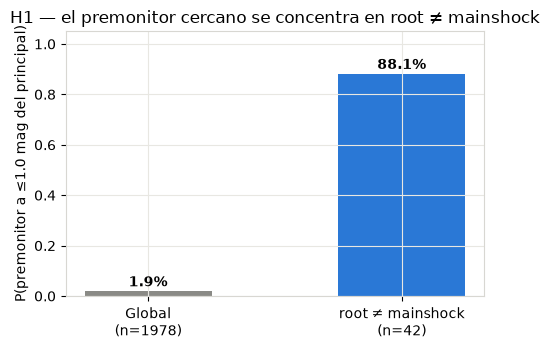

In [16]:
fig, ax = plt.subplots(figsize=(5, 3.6))
grupos = ["Global\n(n=%d)" % len(h1), "root ≠ mainshock\n(n=%d)" % n_discrepantes]
valores = [p_global, p_dado_discrepante]
ax.bar(grupos, valores, color=[GRAY, BLUE], width=0.5)
for i, v in enumerate(valores):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_ylabel("P(premonitor a ≤1.0 mag del principal)")
ax.set_ylim(0, 1.05)
ax.set_title("H1 — el premonitor cercano se concentra en root ≠ mainshock")
fig.tight_layout()
plt.show()

**Medida:** 88.1% de los 42 clusters con `root_is_mainshock = False` tienen un
premonitor a ≤1.0 de magnitud del sismo principal, contra 1.9% en el conjunto
global — **47× más frecuente**.

**Zona:** 🟢 verde — confirma con claridad, la diferencia es enorme y el
patrón tiene sentido físico (un premonitor casi tan grande como el principal
es justo el caso donde "quién es el sismo principal" se vuelve una decisión
de método, no un hecho obvio).

**Decisión:** caracteriza el dominio, pero **no** decide que `root_is_mainshock`
entre al modelo — al revés. Esta corrida usa `mainshock=largest`: el sismo
principal es el evento de mayor magnitud de la secuencia, algo que sólo se
sabe **cuando la secuencia terminó** (podría llegar uno más grande después).
Por eso `root_is_mainshock` (y `n_foreshocks`, que depende de la misma
etiqueta) no están disponibles en el momento de predecir — son fuga, aunque
describan eventos anteriores en el tiempo. Este punto se me había pasado en
la primera versión de esta ficha: lo notó un compañero analizando el mismo
dataset y queda corregido acá y en la tabla de columnas candidatas.

### Ficha 2 — H2 (asociación · predecir)

**Hipótesis:** `n_aftershocks` crece con `mainshock_mag` (ley de
productividad de Utsu), pero la relación no es fuerte ni lineal por el
inflado de ceros del objetivo.

**Pregunta:** predecir (decide si `mainshock_mag` entra al modelo y cómo).

**Plantilla:** asociación — Pearson y Spearman entre `mainshock_mag` y
`n_aftershocks`.

In [17]:
pearson_raw = stats.pearsonr(df.mainshock_mag, df.n_aftershocks)
spearman_raw = stats.spearmanr(df.mainshock_mag, df.n_aftershocks)
print(f"Movimiento 0 (crudo):    Pearson r={pearson_raw.statistic:.3f} (p={pearson_raw.pvalue:.1e}) | "
      f"Spearman rho={spearman_raw.statistic:.3f} (p={spearman_raw.pvalue:.1e})")

# Movimiento 1: cambiar de escala (log1p, porque el objetivo tiene cola larga).
pearson_log = stats.pearsonr(df.mainshock_mag, np.log1p(df.n_aftershocks))
print(f"Movimiento 1 (log1p):    Pearson r={pearson_log.statistic:.3f} (p={pearson_log.pvalue:.1e})")

# Movimiento 2: partir la población (sólo los clusters que sí tuvieron réplicas).
con_replicas = df.n_aftershocks > 0
pearson_nz = stats.pearsonr(df.loc[con_replicas, "mainshock_mag"], df.loc[con_replicas, "n_aftershocks"])
spearman_nz = stats.spearmanr(df.loc[con_replicas, "mainshock_mag"], df.loc[con_replicas, "n_aftershocks"])
print(f"Movimiento 2 (sólo n>0, n={con_replicas.sum()}): Pearson r={pearson_nz.statistic:.3f} (p={pearson_nz.pvalue:.1e}) | "
      f"Spearman rho={spearman_nz.statistic:.3f} (p={spearman_nz.pvalue:.1e})")

# "brecha" (spearman - pearson): si es grande y positiva, la relación es
# monótona pero no lineal — exactamente lo que predice la ley de Utsu
# (crecimiento multiplicativo, no aditivo).
brecha_raw = spearman_raw.statistic - pearson_raw.statistic
brecha_nz = spearman_nz.statistic - pearson_nz.statistic
print(f"brecha (spearman-pearson) cruda: {brecha_raw:.3f} | sólo n>0: {brecha_nz:.3f}")

Movimiento 0 (crudo):    Pearson r=0.393 (p=3.6e-74) | Spearman rho=0.280 (p=4.8e-37)
Movimiento 1 (log1p):    Pearson r=0.518 (p=4.6e-136)
Movimiento 2 (sólo n>0, n=131): Pearson r=0.453 (p=5.4e-08) | Spearman rho=0.550 (p=1.0e-11)
brecha (spearman-pearson) cruda: -0.113 | sólo n>0: 0.097


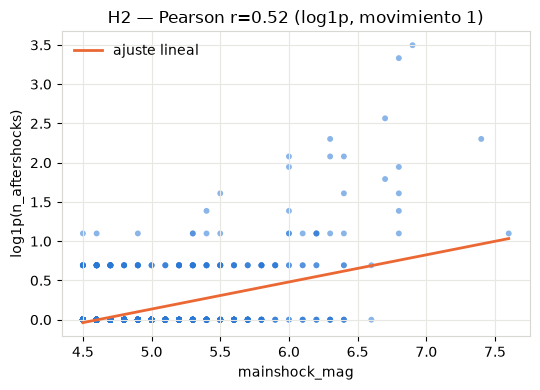

In [18]:
fig, ax = plt.subplots(figsize=(5.5, 4))
ax.scatter(df.mainshock_mag, np.log1p(df.n_aftershocks), s=18, color=BLUE, alpha=0.55, edgecolor="none")

coef = np.polyfit(df.mainshock_mag, np.log1p(df.n_aftershocks), 1)
xs = np.linspace(df.mainshock_mag.min(), df.mainshock_mag.max(), 50)
ax.plot(xs, np.polyval(coef, xs), color=ORANGE, linewidth=2, label="ajuste lineal")

ax.set_xlabel("mainshock_mag")
ax.set_ylabel("log1p(n_aftershocks)")
ax.set_title(f"H2 — Pearson r={pearson_log.statistic:.2f} (log1p, movimiento 1)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

**Medida:** Pearson crudo r=0.393, Spearman rho=0.280 (los rangos se
comprimen por el ~93% de ceros empatados). Con `log1p` (movimiento 1),
Pearson sube a r=0.518. Restringido a los 131 clusters con ≥1 réplica
(movimiento 2), Pearson r=0.453 y Spearman rho=0.550, brecha=0.097. Los tres
Pearson son significativos (p≪0.001) pero, con el corte de correlación de la
cátedra (verde > 0.6), ninguno cruza a verde.

**Zona:** 🟡 amarillo → **inconclusa** con la plantilla de asociación, tras
los dos movimientos permitidos.

**Un compañero midió esta misma pregunta con otra plantilla** (comparación:
agrupa por tramos de magnitud y usa η²) y le dio **verde, η²=0.377** — por
encima del corte de 0.25. No se contradice con el amarillo de acá: Pearson
mide relación **lineal**, y la ley de Utsu es **multiplicativa**
(`réplicas ~ 10^(α·mag)`), no lineal — por eso la brecha (spearman > pearson,
0.097) ya venía avisando que hay una relación monótona que Pearson subestima.
Agrupar por tramos y comparar promedios (en vez de correlacionar punto a
punto) esquiva esa limitación. Los tramos de los compañeros: pendiente en
escala log10 ≈ 1.05, o sea que cada punto de magnitud multiplica las réplicas
promedio por ≈11×.

**Zona (comparación, tramos de magnitud):** 🟢 verde (η²=0.377, referencia
externa a este notebook).

**Decisión:** `mainshock_mag` **entra al modelo**, con un enlace logarítmico
(Poisson / binomial negativa, no una regresión lineal) — las dos plantillas
coinciden en que la relación es real y monótona, y la de comparación deja
ver además que es multiplicativa. Igual no alcanza sola: el modelo de la
Unidad 3 va a necesitar más features y, probablemente, una estructura de dos
etapas (¿hay réplicas? / cuántas) dado el inflado de ceros — mismo punto que
7.6.

### Ficha 3 — H3 (asociación · predecir, chequeo de fuga)

**Hipótesis:** `n_events` predice `n_aftershocks` casi perfectamente porque
son la misma cantidad disfrazada: `n_events = n_aftershocks + n_foreshocks +
1` es una identidad del pipeline (invariante documentado en
`EXPLICACION_PROYECTO.md`), no una relación estadística.

**Pregunta:** predecir (decide si `n_events` puede entrar al modelo).

**Plantilla:** asociación — Pearson y Spearman entre `n_events` y
`n_aftershocks`, más la verificación directa de la identidad.

In [19]:
identidad_rota = (df.n_events - 1 - df.n_foreshocks - df.n_aftershocks) != 0
print("filas donde n_events - 1 - n_foreshocks - n_aftershocks != 0:", identidad_rota.sum())

pearson_fuga = stats.pearsonr(df.n_events, df.n_aftershocks)
spearman_fuga = stats.spearmanr(df.n_events, df.n_aftershocks)
print(f"Pearson r={pearson_fuga.statistic:.4f} (p={pearson_fuga.pvalue:.1e})")
print(f"Spearman rho={spearman_fuga.statistic:.4f} (p={spearman_fuga.pvalue:.1e})")

filas donde n_events - 1 - n_foreshocks - n_aftershocks != 0: 0
Pearson r=0.9781 (p=0.0e+00)
Spearman rho=0.9038 (p=0.0e+00)


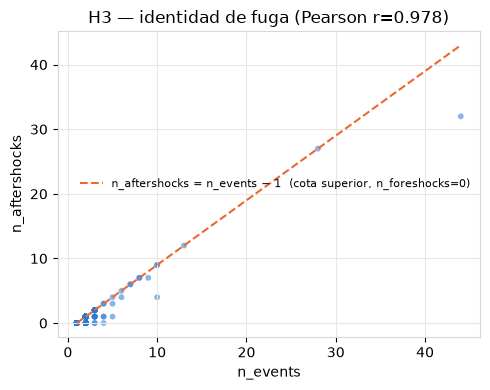

In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(df.n_events, df.n_aftershocks, s=18, color=BLUE, alpha=0.55, edgecolor="none")
xs = np.array([df.n_events.min(), df.n_events.max()])
ax.plot(xs, xs - 1, color=ORANGE, linewidth=1.5, linestyle="--",
        label="n_aftershocks = n_events − 1  (cota superior, n_foreshocks=0)")
ax.set_xlabel("n_events")
ax.set_ylabel("n_aftershocks")
ax.set_title(f"H3 — identidad de fuga (Pearson r={pearson_fuga.statistic:.3f})")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

**Medida:** la identidad se cumple exactamente en las 1978 filas (0
excepciones) y Pearson r=0.978 / Spearman rho=0.904. Un compañero llegó al
mismo Pearson (0,978) midiéndolo por separado sobre el mismo CSV — la fuga no
depende de cómo se calculó.

**Zona:** 🟢 verde — confirma con claridad, es prácticamente determinístico.

**Decisión:** `n_events` **sale por fuga**. No existiría en el momento de
predecir: sólo se conoce el tamaño final del cluster (principal + réplicas +
premonitores) después de que la secuencia terminó, es decir, después de
conocer la respuesta. Lo mismo aplica, por construcción, a `duration_days`,
`extent_km` y `max_generation` (ver tabla de columnas candidatas) — los
cuatro se calculan recorriendo el cluster ya armado, réplicas incluidas.

### Ficha 4 — H4 (comparación · responder, calidad del método)

**Hipótesis:** el thinning probabilístico (`is_aftershock`) discrepa del
corte duro por umbral (`is_aftershock_eta`) más cerca del umbral
`log₁₀η₀` que lejos de él — el sorteo sólo debería mover a los eventos
ambiguos, no a los que están claramente de un lado.

**Pregunta:** responder (caracteriza la calidad del método, conecta con el
punto 7.6 abierto de la Entrega 1).

**Plantilla:** comparación — separación estandarizada (Cohen's d) de la
distancia `|log10_eta − umbral|` entre el grupo que coincide
(`is_aftershock == is_aftershock_eta`) y el que discrepa.

In [21]:
import json

with open(glob.glob("../pipeline/include/output/detector_replicas_api/threshold/*.json")[0]) as fh:
    umbral_info = json.load(fh)
UMBRAL = umbral_info["log10_eta0"]
print("log10(eta0) de esta corrida:", round(UMBRAL, 3))

ev4 = events.dropna(subset=["log10_eta"]).copy()
ev4["dist_umbral"] = (ev4.log10_eta - UMBRAL).abs()
coinciden = ev4.is_aftershock == ev4.is_aftershock_eta

g_coinciden = ev4.loc[coinciden, "dist_umbral"]
g_discrepan = ev4.loc[~coinciden, "dist_umbral"]

n1, n2 = len(g_coinciden), len(g_discrepan)
sd_combinada = np.sqrt(((n1 - 1) * g_coinciden.std(ddof=1) ** 2 + (n2 - 1) * g_discrepan.std(ddof=1) ** 2) / (n1 + n2 - 2))
cohen_d = (g_discrepan.mean() - g_coinciden.mean()) / sd_combinada

t = stats.ttest_ind(g_discrepan, g_coinciden, equal_var=False)

print(f"coinciden: {n1} ({n1/len(ev4):.1%}) | discrepan: {n2} ({n2/len(ev4):.1%})")
print(f"media |dist. al umbral| coinciden={g_coinciden.mean():.3f} | discrepan={g_discrepan.mean():.3f}")
print(f"Cohen's d = {cohen_d:.3f}  (Welch t={t.statistic:.2f}, p={t.pvalue:.1e})")

banda = 0.5
print(f"P(|dist|<={banda} | discrepan) = {(g_discrepan <= banda).mean():.1%}")
print(f"P(|dist|<={banda} | coinciden)  = {(g_coinciden <= banda).mean():.1%}")

log10(eta0) de esta corrida: -5.778
coinciden: 2209 (95.2%) | discrepan: 111 (4.8%)
media |dist. al umbral| coinciden=1.608 | discrepan=0.864
Cohen's d = -0.984  (Welch t=-8.70, p=2.3e-14)
P(|dist|<=0.5 | discrepan) = 49.5%
P(|dist|<=0.5 | coinciden)  = 6.2%


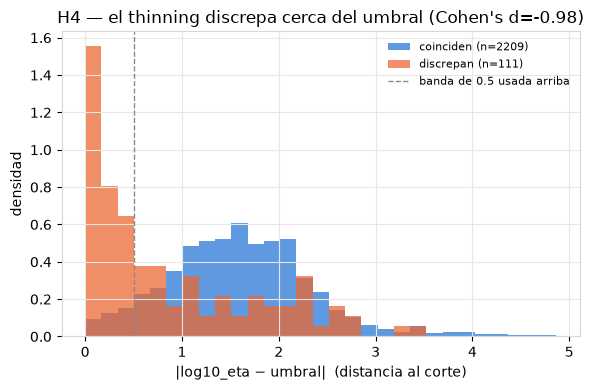

In [22]:
fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(0, ev4.dist_umbral.max(), 30)
ax.hist(g_coinciden, bins=bins, color=BLUE, alpha=0.75, label=f"coinciden (n={n1})", density=True)
ax.hist(g_discrepan, bins=bins, color=ORANGE, alpha=0.75, label=f"discrepan (n={n2})", density=True)
ax.axvline(0.5, color=GRAY, linestyle="--", linewidth=1, label="banda de 0.5 usada arriba")
ax.set_xlabel("|log10_eta − umbral|  (distancia al corte)")
ax.set_ylabel("densidad")
ax.set_title(f"H4 — el thinning discrepa cerca del umbral (Cohen's d={cohen_d:.2f})")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

**Medida:** Cohen's d = −0.98 (casi 1 desvío) entre la distancia al umbral de
los eventos que discrepan contra los que coinciden (Welch t=−8.70,
p=2.3e-14). Dentro de una banda de ±0.5 en `log10_eta` alrededor del umbral
cae el 49.5% de las discrepancias, contra sólo 6.2% de las coincidencias —
**8× más concentradas cerca del corte**.

**Zona:** 🟢 verde — confirma con claridad. El sorteo hace exactamente lo que
tiene que hacer: mueve a los eventos ambiguos (cerca del valle entre las dos
gaussianas) y deja casi intactos a los que están lejos del umbral.

**Decisión:** no es una columna candidata para el modelo de clusters, pero
**documenta por qué el objetivo está inflado de ceros con este nivel de
detalle**: la frontera réplica/fondo no es una línea limpia, sino una zona
gris de ~50 eventos donde el método admite que no sabe. Para el modelo de
`events_*.csv` (si se usa esa unidad de análisis) esto sugiere considerar
`p_background` como target/feature continuo en vez de forzar el binario
`is_aftershock` cerca del umbral.

## 3. Tabla de columnas candidatas — `clusters_*.csv` para el modelo de la Unidad 3

El chequeo de fuga es la columna que importa: **¿esa columna existiría en el
momento de predecir?** — y acá "el momento de predecir" hay que definirlo con
cuidado, porque esta corrida usa `mainshock=largest`: el sismo principal es
el evento de **mayor magnitud** de toda la secuencia, algo que sólo queda
determinado **cuando la secuencia terminó** (un evento más grande podría
llegar después). Eso tiene dos consecuencias:

- `mainshock_mag`, `mainshock_lat/lon`, `mainshock_depth`, `mainshock_time`
  son atributos del evento en sí — se conocen apenas ese evento ocurre,
  aunque todavía no se sepa con certeza que *ese* evento va a terminar siendo
  "el principal" (ver H1). Entran con esa salvedad.
- `n_foreshocks` y `root_is_mainshock` son distintos: describen la
  **estructura del cluster ya resuelta** (qué eventos quedaron antes del
  principal *una vez que se supo quién era*), así que dependen de la misma
  etiqueta que todavía no está resuelta en el momento de predecir. **Fugan**,
  aunque los eventos que cuentan hayan ocurrido antes en el tiempo — esto se
  me había pasado en la ficha 1 original y lo corrijo acá (ver H1).
- `n_events`, `duration_days`, `extent_km`, `max_generation` se calculan
  recorriendo el cluster ya cerrado —réplicas incluidas— así que fugan por la
  razón más directa (H3): incluyen la respuesta.

Antes de la tabla, dos columnas que todavía no tenían número propio:

In [23]:
# mainshock_lat / mainshock_lon contra el objetivo — mismo chequeo que hizo
# un compañero sobre el mismo dataset.
coords = pd.DataFrame({
    col: {"pearson": stats.pearsonr(df[col], df.n_aftershocks).statistic}
    for col in ["mainshock_lat", "mainshock_lon"]
}).T
coords

,pearson
mainshock_lat,-0.033581
mainshock_lon,-0.063464


In [24]:
# mainshock_place es texto libre del USGS ("distancia + referencia + país");
# separar por coma y quedarse con el último campo aproxima el país.
df["mainshock_place"].str.split(", ").str[-1].value_counts(normalize=True).head(8)

mainshock_place
Chile                            0.563701
Argentina                        0.389788
Bolivia                          0.032356
Falkland Islands region          0.007078
Chile-Argentina border region    0.005561
Chile-Bolivia border region      0.001517
Name: proportion, dtype: float64

In [25]:
columnas_candidatas = pd.DataFrame([
    ("cluster_id", "Clave: id del evento raíz del cluster.", "—", "Sale (es la clave, no una feature)", "—"),
    ("mainshock_id", "Id del sismo principal en el catálogo USGS.", "—", "Sale (identificador, sin valor predictivo)", "Sí, pero no informa"),
    ("mainshock_place", "Descripción de lugar en texto libre del USGS.", "—", "Sale cruda / entra transformada — el país aproximado por el último campo del texto (arriba) podría ser categórica, pero la ubicación ya está en lat/lon", "Sí"),
    ("mainshock_mag", "Magnitud del sismo principal.", "amarillo (H2, asociación) / verde (H2, comparación por tramos)", "Entra — con enlace logarítmico (Poisson/BN), no lineal", "Sí, con la salvedad de arriba"),
    ("mainshock_time", "Hora UTC del sismo principal.", "—", "Sale cruda como feature / se usa para partir train y test por tiempo en la Unidad 3", "Sí, con la salvedad de arriba"),
    ("mainshock_lat", "Latitud del epicentro del sismo principal.", "rojo (Pearson ≈ -0.03)", "Sale de la primera versión — sin asociación marginal con el objetivo", "Sí, con la salvedad de arriba"),
    ("mainshock_lon", "Longitud del epicentro del sismo principal.", "rojo (Pearson ≈ -0.06)", "Sale de la primera versión — sin asociación marginal con el objetivo", "Sí, con la salvedad de arriba"),
    ("mainshock_depth", "Profundidad del sismo principal, en km.", "—", "Entra a evaluar — sin hipótesis propia en este notebook sobre profundidad vs réplicas", "Sí, con la salvedad de arriba"),
    ("n_events", "Tamaño del cluster: principal + réplicas + premonitores.", "verde (H3)", "Sale por fuga — n_events = n_aftershocks + n_foreshocks + 1", "No — incluye la respuesta"),
    ("n_foreshocks", "Eventos del cluster anteriores al sismo principal.", "verde (H1, como caracterización de dominio)", "Sale por fuga — depende de saber quién es el principal, y eso se resuelve al final de la secuencia", "No"),
    ("duration_days", "Días entre el primer y el último evento del cluster.", "—", "Sale por fuga — el último evento puede ser una réplica", "No"),
    ("extent_km", "Distancia máxima del principal a cualquier evento del cluster.", "—", "Sale por fuga — se mide contra réplicas incluidas", "No"),
    ("max_generation", "Profundidad de la cadena de réplicas.", "—", "Sale por fuga — sólo existe si ya hubo réplicas", "No"),
    ("root_is_mainshock", "Si la raíz del árbol coincide con el sismo principal.", "verde (H1, como caracterización de dominio)", "Sale por fuga — misma razón que n_foreshocks", "No"),
    ("n_aftershocks", "Objetivo.", "—", "Es el target, no una feature", "—"),
], columns=["Columna", "Qué mide", "Zona (hipótesis)", "Decisión", "¿Existiría al predecir?"])

columnas_candidatas

,Columna,Qué mide,Zona (hipótesis),Decisión,¿Existiría al predecir?
0,cluster_id,Clave: id del evento raíz del cluster.,—,"Sale (es la clave, no una feature)",—
1,mainshock_id,Id del sismo principal en el catálogo USGS.,—,"Sale (identificador, sin valor predictivo)","Sí, pero no informa"
2,mainshock_place,Descripción de lugar en texto libre del USGS.,—,Sale cruda / entra transformada — el país apro...,Sí
3,mainshock_mag,Magnitud del sismo principal.,"amarillo (H2, asociación) / verde (H2, compara...","Entra — con enlace logarítmico (Poisson/BN), n...","Sí, con la salvedad de arriba"
4,mainshock_time,Hora UTC del sismo principal.,—,Sale cruda como feature / se usa para partir t...,"Sí, con la salvedad de arriba"
5,mainshock_lat,Latitud del epicentro del sismo principal.,rojo (Pearson ≈ -0.03),Sale de la primera versión — sin asociación ma...,"Sí, con la salvedad de arriba"
6,mainshock_lon,Longitud del epicentro del sismo principal.,rojo (Pearson ≈ -0.06),Sale de la primera versión — sin asociación ma...,"Sí, con la salvedad de arriba"
7,mainshock_depth,"Profundidad del sismo principal, en km.",—,Entra a evaluar — sin hipótesis propia en este...,"Sí, con la salvedad de arriba"
8,n_events,Tamaño del cluster: principal + réplicas + pre...,verde (H3),Sale por fuga — n_events = n_aftershocks + n_f...,No — incluye la respuesta
9,n_foreshocks,Eventos del cluster anteriores al sismo princi...,"verde (H1, como caracterización de dominio)",Sale por fuga — depende de saber quién es el p...,No


**Conclusión de la tabla:** la primera versión del modelo arranca con
`mainshock_mag` (con enlace logarítmico) y `mainshock_depth` como features
principales, sin ninguna columna que dependa de saber cómo terminó la
secuencia. Las columnas que más "explicaban" el objetivo a simple vista
(`n_events`, `n_foreshocks`, `root_is_mainshock`) salen todas por el mismo
motivo — o incluyen la respuesta, o dependen de una etiqueta que recién se
resuelve al final de la secuencia (`mainshock=largest`). Iban a dar un modelo
buenísimo por el peor de los motivos.

## 4. Puntos pendientes de la Entrega 1

| # | Punto | Estado |
|---|---|---|
| 7.5 | Ventana de fechas tiene que ser larga | Sin cambios — se usó la ventana de referencia (2016–2026), `estimate_mc`/`publish_csv` no fallaron. |
| **7.6** | **Target inflado de ceros** | **Resuelto en esta entrega** (ver abajo). |
| 7.7 | Números inconsistentes en `README.md` (4.6%→2.1%, R²=0.996→0.991) | Resuelto directo en el README, alineado con la tabla de referencia. |

### 7.6 — Target inflado de ceros, con número

`n_aftershocks` (clusters): 93.4% en cero, contra 6.6% con al menos una
réplica (131 de 1978). El objetivo equivalente a nivel evento,
`is_aftershock`, da 14.8% de `True` — menos extremo, porque ahí la unidad de
análisis es el evento individual y no el cluster completo.

**Qué implica para la Unidad 3:** un regresor lineal/Poisson simple sobre
`n_aftershocks` va a estar dominado por predecir "0" — la ley de Utsu (H2) da
señal real pero moderada. Conviene evaluar:

- un modelo en dos etapas (clasificar "¿va a tener réplicas?" y, si sí,
  regresión sobre cuántas), o
- una binomial negativa / Poisson con inflado de ceros (ZINB / ZIP) sobre
  `n_aftershocks` directamente.

No se resuelve en esta entrega — es la entrada de la Unidad 3 — pero ya no es
"algo que se menciona de pasada": queda con el número (93.4%) y con las dos
rutas de modelado que habilita.

## 5. Qué cambió al comparar con el notebook de un compañero

Un compañero del grupo armó su propio EDA sobre el mismo `clusters_*.csv`
(`Análisis Exploratorio de Sismos (clusters).ipynb`, con sus propias 4
hipótesis, no versionado en este archivo). Cruzarlo con este notebook sirvió
para tres cosas:

- **Corrigió un error real acá:** `n_foreshocks` y `root_is_mainshock`
  pasaron de "entra" a "sale por fuga" (ficha 1 y tabla de columnas
  candidatas) — con `mainshock=largest`, quién es el sismo principal sólo se
  sabe cuando termina la secuencia, así que cualquier columna que dependa de
  esa etiqueta ya resuelta fuga, aunque describa eventos anteriores en el
  tiempo.
- **Corroboró de forma independiente** la fuga de `n_events` (mismo Pearson,
  0.978, calculado por separado) y la dirección de la ley de Utsu — la
  reformulación por tramos de magnitud (η²=0.377, verde) fortalece la ficha
  2 en vez de contradecirla (ver ahí el porqué).
- **Abrió una pregunta que no está resuelta en ningún de los dos
  notebooks:** el dataset entero se armó con `mainshock=largest`, que es la
  convención de Zaliapin & Ben-Zion pero no la más parecida a "lo que se
  sabe en el momento de predecir" (para eso serviría más `mainshock=root`,
  el evento que abrió la secuencia, conocido apenas ocurre). Afecta a las 42
  secuencias (2.1%) donde discrepan — la misma cifra de la ficha 1 — y
  conviene evaluarlo en la Unidad 3, no acá.

El compañero también tiene dos hipótesis refutadas con buena metodología que
no entraron en este notebook por no duplicar cobertura (cuatro fichas ya
mezclan `responder`/`predecir` y tienen una no-verde): profundidad del
sismo principal vs cantidad de réplicas (separación=0.134 y η²=0.0055, las
dos en rojo — conecta con el pendiente de "corte por profundidad" del
`README.md`) y estacionalidad, año/mes vs réplicas (η²≈0.005 en los dos,
rojo). Vale tenerlas presentes para la defensa aunque no sean de las cuatro
fichas oficiales de este archivo.

## 6. Conclusión

El perfil confirma que el dataset cumple los criterios medibles de la
consigna (clave sin duplicados —de `cluster_id` y también de `mainshock_id`—,
sin columnas constantes, sin nulos "sucios" en `clusters_*.csv`, un solo nulo
estructural en `events_*.csv`) y deja identificado el problema real para
modelar: el inflado de ceros del objetivo. De las cuatro hipótesis, tres
confirman con claridad (H1, H3, H4) y una queda inconclusa con su plantilla
original (H2) tras agotar los dos movimientos permitidos — aunque una
plantilla distinta, cruzada con un compañero, la confirma en verde por otro
camino. La tabla de columnas candidatas deja seis columnas fuera por fuga
(`n_events`, `duration_days`, `extent_km`, `max_generation`, y —corregido
tras comparar notebooks— `n_foreshocks` y `root_is_mainshock`) antes de
llegar a la Unidad 3.